# GTensor Pipeline Example Notebook
This notebook demonstrates how to use the `OutToJsonConverter`, `GTensorConfig`, and `GTensorPipeline` classes to process a Q-Chem `.out` file, convert it to JSON, load the data, and compute the g-shift.

The workflow is as follows:
1. Load the `.out` file.
2. Convert it to JSON format.
3. Configure GTensor options.
4. Run the full pipeline: load → select states → calculate g-shift.

Make sure that the project environment is correctly installed and that imports work from your package structure.


In [21]:
from pathlib import Path
import sys

myproject = Path.cwd().parent.parent # ← ADJUST "Path.cwd().parent"
if str(myproject) not in sys.path:
    sys.path.append(str(myproject))
print(myproject)

# %load_ext autoreload
# %autoreload 2

c:\Users\111510\proyects\gmatrix_state_interaction


In [22]:
from tatchen_method.gmatrix_program.gmatrix_classes import OutToJsonConverter, GTensorConfig, GTensorPipeline
%matplotlib inline

## Load Q-Chem Output File
Provide the path to a Q-Chem `.out` file. In a normal script this would be taken from command-line arguments, but here we define it manually.

In [23]:
qchemout = 'test_1.out'  # Modify with your actual path
qchemout

'test_1.out'

## Convert OUT → JSON
The converter reads the `.out` file, parses the contents, and saves the resulting data to a structured JSON file.

In [24]:
converter = OutToJsonConverter(qchemout)
converter.read_file()
converter.parse()
converter.save_json()

## Configure GTensor Calculation
You can adjust the configuration to select states, restrict calculations, or change analysis modes.

In [25]:
config = GTensorConfig()
config.state_selection = 0
config.initial_states = [1, 2, 3, 4, 5, 6] 

## Run GTensor Pipeline
Pipeline steps:
1. Load the JSON data.
2. Select states.
3. Run g-shift calculation.

In [26]:
pipeline = GTensorPipeline(qchemout, config=config)
pipeline.load_data()
pipeline.select_states()
pipeline.run_gshift_calculation()


---------------------
 G-SHIFT RESULTS
---------------------
File selected:  test_1.out
SOC:  All orders , All BP Hamiltonian
States:  [1, 2, 3, 4, 5, 6]
States multiplicity: 
- triplet = 6: [1, 2, 3, 4, 5, 6]
g-factor (x y z dimensions) in ppt: 2.845 2.845 -0.002



Optional analyses (commented out) include sum-over-states, pairs analysis, and S² comparison.

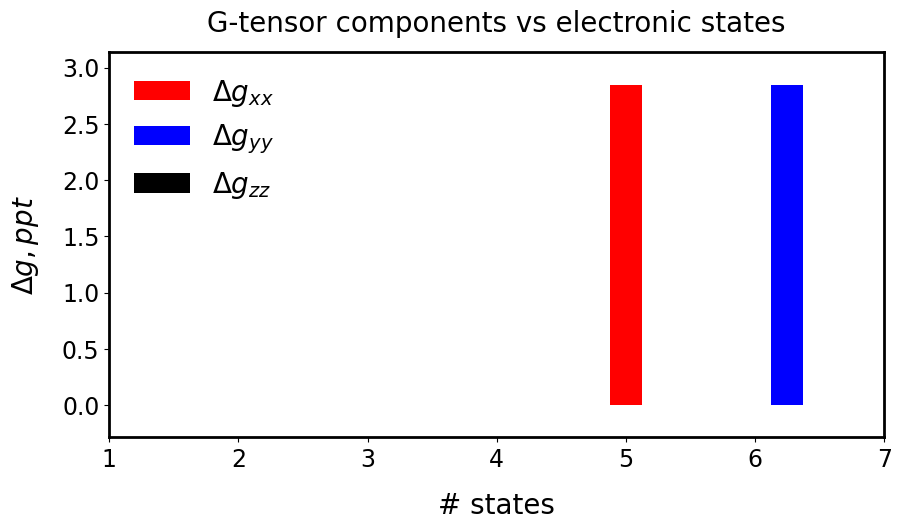

In [27]:
pipeline.run_sos_analysis()

In [28]:
pipeline.run_pairs_analysis()           # Optional

----------------------
 G-TENSOR ANALYSIS
----------------------
cut-offs: 
- g-shift estimation (%): 0
- configurations (%):  0
- somos to add to new active space:  [8, 9]

state config. amplitude somo gxx gyy gzz
    1       0     0.999  8,9  --  --  --

------------------------
 EXCITED STATES ANALYSIS
------------------------
cut-offs: 
- configurations (%):  0
- soccs (%):  0
- angular momentum (%):  0

state spin config. amplitude somo  energy excit. energy    socc          angmom
    1  2.0       0     0.999  8,9 -149.66           0.0      --              --
    2  2.0       0     0.706  7,9  -149.5        4.3066     0.0       -0j,0j,0j
    2  2.0       1     0.706  6,8  -149.5        4.3066     0.0       -0j,0j,0j
    3  2.0       0     0.706  7,8  -149.5        4.3066     0.0     -0j,-0j,-0j
    3  2.0       1    -0.706  6,9  -149.5        4.3066     0.0     -0j,-0j,-0j
    4  2.0       0     0.707  6,8  -149.5        4.4828     0.0       0j,0j,-0j
    4  2.0       1    -0.707

In [29]:
pipeline.run_s2_comparison()

TypeError: sum_over_state_plot() missing 1 required positional argument: 'sos_print_results'

In [ ]:
pipeline.run_scaling_analysis()